<a href="https://colab.research.google.com/github/irembagcivan/Veri-Bilimi-Bootcamp/blob/main/Python_Oturum_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Drive Bağlantısı

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
veri_yolu='/content/drive/MyDrive/TECH ISTANBUL/Advertising.csv'

##Veri

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#matplotlib: Grafikler, çizimler ve veri görselleştirmeleri oluşturmayı sağlayan temel Python kütüphanesidir.
#.pyplot: Matplotlib içindeki grafik oluşturma komutlarını (çizme, başlık ekleme, eksenleri ayarlama vb.) içeren alt modüldür.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
veri = pd.read_csv(veri_yolu)

In [ ]:
X = veri[['TV', 'Radio', 'Newspaper']]
y = veri['Sales']

In [ ]:
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state= 34)

##Model Oluşturma

In [ ]:
model = LinearRegression() # Makine öğrenmesi algoritmasını hafızada boş bir nesne olarak tanımlar ve kullanıma hazır hale getirir.
model.fit(X_train, y_train) # Modelin veriyi incelediği aşamadır.

LinearRegression()

##Tahmin


In [ ]:
y_pred = model.predict(X_test)

##Hata Hesaplama


In [ ]:
mse = mean_squared_error(y_pred, y_test)
print('Hata skoru: ', mse)

Hata skoru:  3.1911211213641772


##Katsayılar ve Kesişim


In [ ]:
print('Katsayılar: ', model.coef_)
print('Kesişim: ', model.intercept_)

Katsayılar:  [ 0.04698715  0.19360408 -0.00120282]
Kesişim:  2.5569314844318374


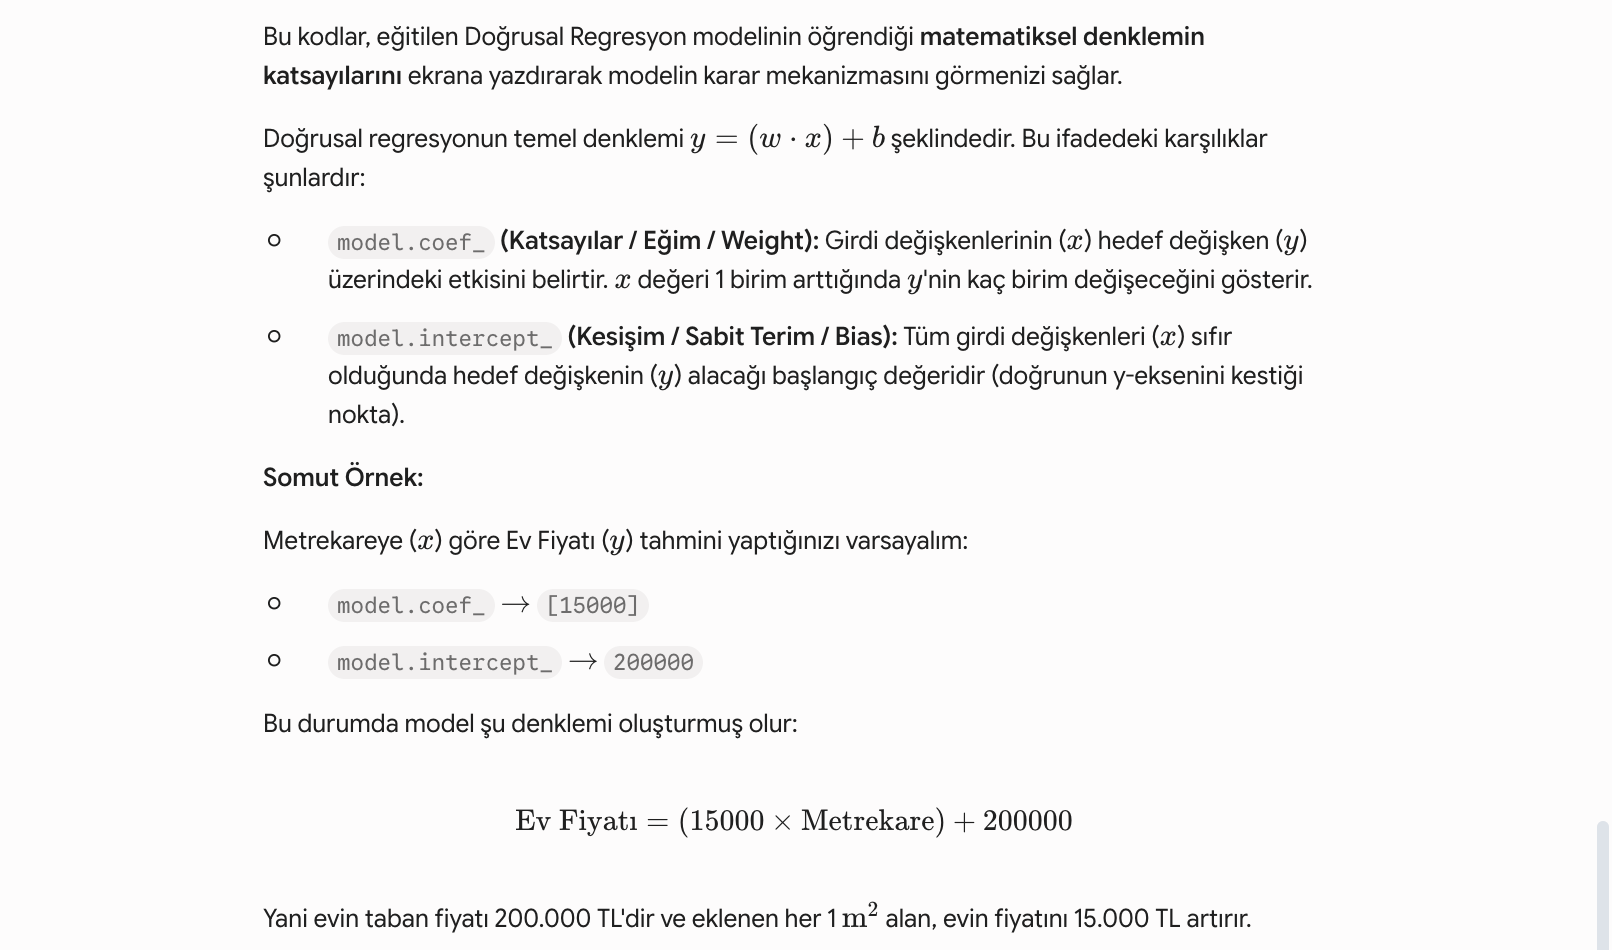

#EV FİYATLARI

##Veri Seti


In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
evler = fetch_california_housing()
veri = pd.DataFrame(evler.data, columns= evler.feature_names)
veri['PRICE'] = evler.target

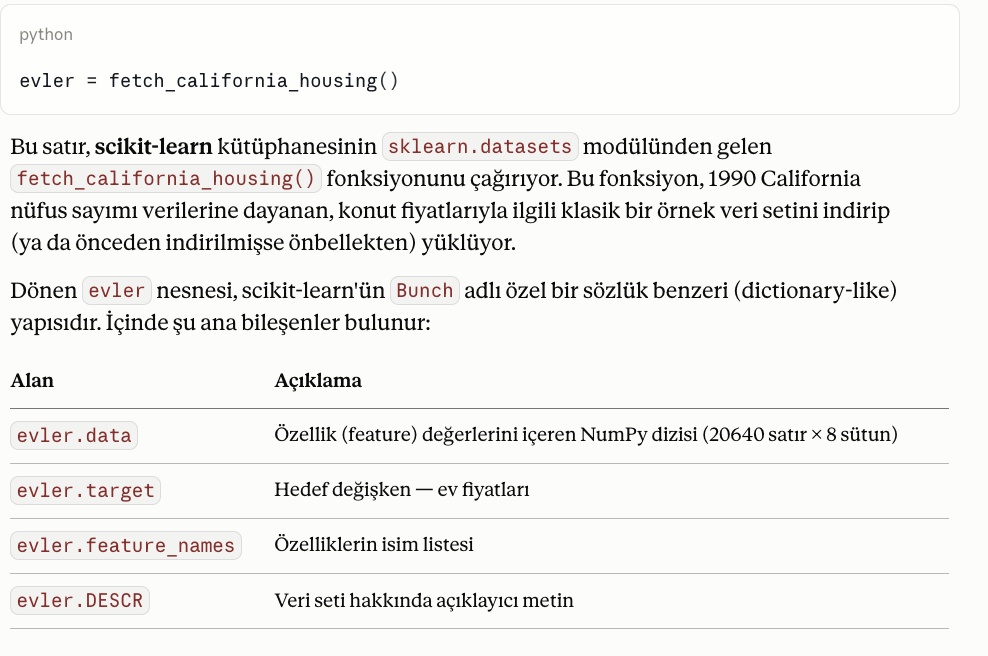

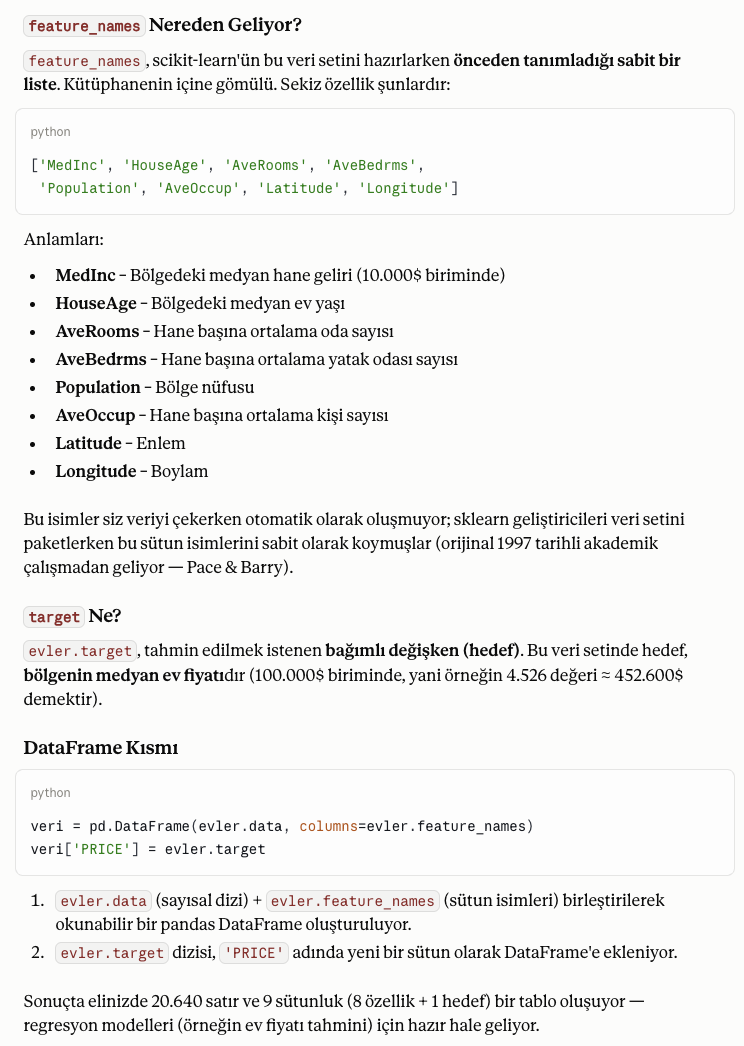

In [ ]:
print(veri.head(10))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
5    -122.25  2.697  
6    -122

In [ ]:
X = veri.drop('PRICE', axis = 1)
# axis parametresi hangi yönde sütun sileceğimizi söyler.
# axis = 0 ise satırlar silinir.
# axis = 1 ise sütunlar silinir. biz price sütununu silmek istediğimiz için 1 yazarız


In [ ]:
y = veri['PRICE']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state = 42)

##Doğrusal Regresyon

In [ ]:
dogrusal_model = LinearRegression()
dogrusal_model.fit(X_train, y_train)

LinearRegression()

##Tahmin

In [ ]:
y_pred = dogrusal_model.predict(X_test)

##Hata Hesaplama

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print('Hata skoru: ', mse)

Hata skoru:  0.5218435360402411


##PCR
Amaç değişken sayısını azaltmaktır.

PCR = PCA (boyut indirgeme) + Doğrusal Regresyon

Adım 1: Verilerin standartlaştırılması

Adım 2: PCA

Adım 3: PCR modeli oluşturma

In [ ]:
from sklearn.decomposition import PCA
from sklearn. preprocessing import StandardScaler

In [ ]:
olcek = StandardScaler() # her sütunu(özelliği) standartlaştırmak için kullanılır
X_olcekli = olcek.fit_transform(X)
print(X_olcekli)

[[ 2.34476576  0.98214266  0.62855945 ... -0.04959654  1.05254828
  -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 ... -0.09251223  1.04318455
  -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 ... -0.02584253  1.03850269
  -1.33282653]
 ...
 [-1.14259331 -0.92485123 -0.09031802 ... -0.0717345   1.77823747
  -0.8237132 ]
 [-1.05458292 -0.84539315 -0.04021111 ... -0.09122515  1.77823747
  -0.87362627]
 [-0.78012947 -1.00430931 -0.07044252 ... -0.04368215  1.75014627
  -0.83369581]]


**fit:** Her sütunun ortalamasını ve standart sapmasını hesaplıyor.

**transform:** Her değeri şu formülle dönüştürüyor:


> z = ( x - ortalama ) / standart sapma



##PCA

In [ ]:
pca = PCA(n_components=6) # 8 orijinal özelliği 4 yeni "temel bileşene" indirgiyor.
X_pca = pca.fit_transform(X_olcekli) # önce PCA'yı veriye öğretiyor (fit) sonra veriyi 4 boyuta dönüştürüyor (transform)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Hata skoru: ", mse)

Hata skoru:  0.6676194933473529


##PLS (PCR'ın Akıllı Versiyonu)
PCR'ın sorunu neydi?

PCA, bileşenleri seçerken y (hedef değişken/fiyat) hakkında hiçbir şey bilmiyordu — sadece X'in kendi içindeki varyansa bakıyordu.

PLS bunu düzeltir: bileşenleri seçerken hem X'in varyansını HEM DE y ile olan ilişkisini dikkate alır.

In [ ]:
from sklearn.cross_decomposition import PLSRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_olcekli, y, test_size=0.2, random_state=42)

In [ ]:
pls = PLSRegression(n_components=7)
pls.fit(X_train, y_train)

PLSRegression(n_components=7)

In [ ]:
y_pred = pls.predict(X_test)

In [ ]:
mse = mean_squared_error(y_pred, y_test)
print('Hata skoru: ', mse)

Hata skoru:  0.5557044298058964


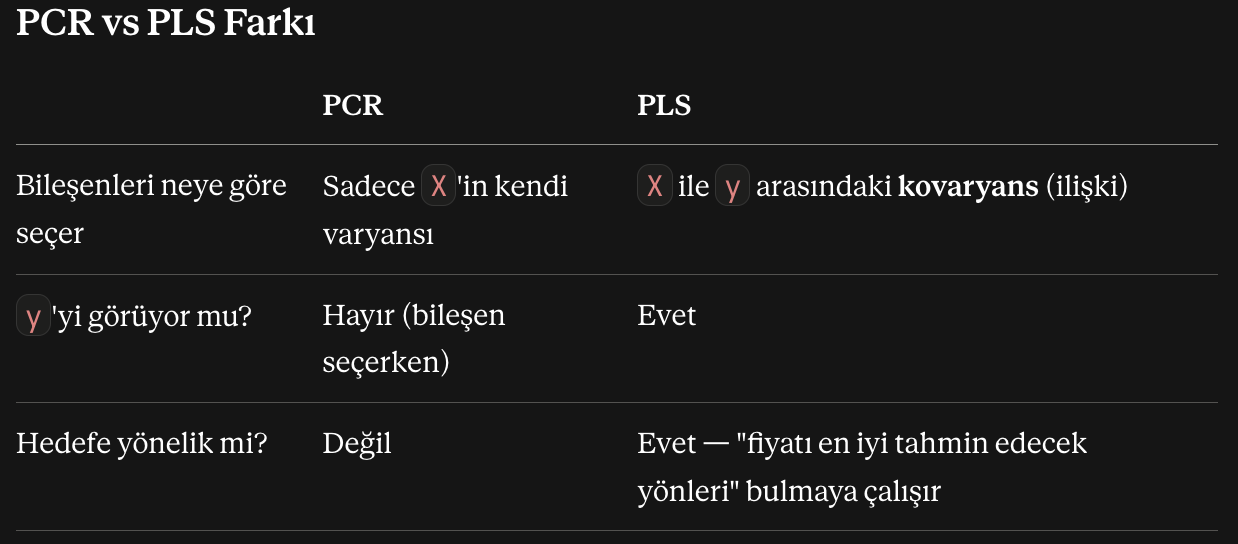

##Ridge
Ridge, normal doğrusal regresyonun (Linear Regression) "cezalı" (regularized) bir versiyonudur. Buraya kadar gördüğümüz PCR ve PLS "boyut indirgeme" mantığıyla çalışıyordu; Ridge ise tamamen farklı bir yaklaşım kullanır — boyutu değiştirmez, bunun yerine katsayıları (coefficients) sınırlar.

Normal Regresyon Neden Sorunlu Olabilir?

Normal doğrusal regresyon, hatayı en aza indirmeye çalışırken bazen katsayılara (β değerlerine) aşırı büyük değerler verebilir — özellikle özellikler birbiriyle ilişkiliyse (multicollinearity). Bu, modelin eğitim verisine aşırı uyum sağlamasına (overfitting) yol açabilir.

Yani model artık sadece "tahmini doğru yapmaya" değil, aynı zamanda "katsayıları küçük tutmaya" da zorlanıyor. Bu ceza, katsayıların çok büyük değerlere sıçramasını engelliyor ve modeli daha "sakin"/kararlı hale getiriyor.


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge = Ridge(alpha=10)
# alpha ceza teriminin gücünü kontrol eder.
# alpha = 0, ceza yok | alpha = küçükse, hafif ceza | alpha = büyükse, güçlü ceza katsayılar 0' a yaklaştırılır
ridge.fit(X_train, y_train)

Ridge(alpha=10)

In [ ]:
y_pred = ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('Hata skoru: ', mse)

Hata skoru:  0.5554993268848043


##Doğrusal Olmayan Modeller

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsRegressor

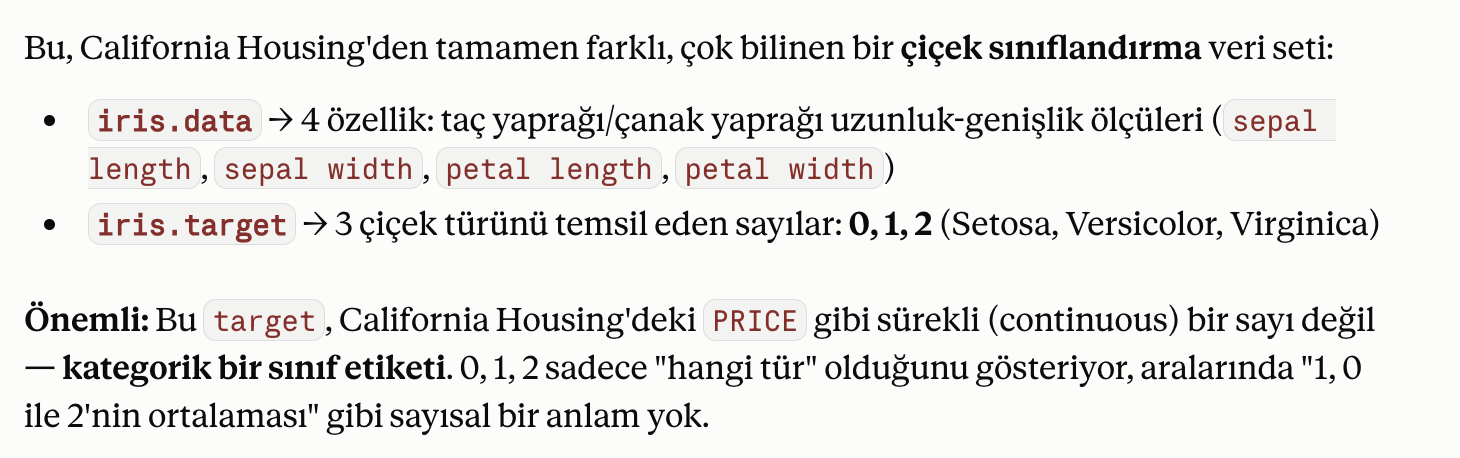

In [ ]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['Target'] = iris.target
print(data.head(100))

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
..                ...               ...                ...               ...   
95                5.7               3.0                4.2               1.2   
96                5.7               2.9                4.2               1.3   
97                6.2               2.9                4.3               1.3   
98                5.1               2.5                3.0               1.1   
99                5.7               2.8                4.1               1.3   

    Target  
0        0  
1        0  


In [ ]:
X = iris.data
y= iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state =42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3) # En yakın 3 komşunun ortalamasını al, tahmin bu olsun
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn = knn.predict(X_test)
from sklearn.metrics import accuracy_score
dogruluk = accuracy_score(y_test, y_pred_knn)
print("Doğruluk oranı: ", dogruluk)

Doğruluk oranı:  1.0


##SVR (SVM'nin Regresyon Versiyonu)
Normal regresyon "hatayı en aza indir" derken, SVR biraz farklı bir mantık kullanır:

"Belirli bir tolerans payı (epsilon) içindeki hataları görmezden gel, sadece bu payın dışına çıkan hatalara ceza ver."



In [ ]:
from sklearn.svm import SVR

In [ ]:
epsilon = 0.1
svr = SVR(kernel='linear', epsilon=epsilon)
svr.fit(X_train,y_train)

SVR(kernel='linear')

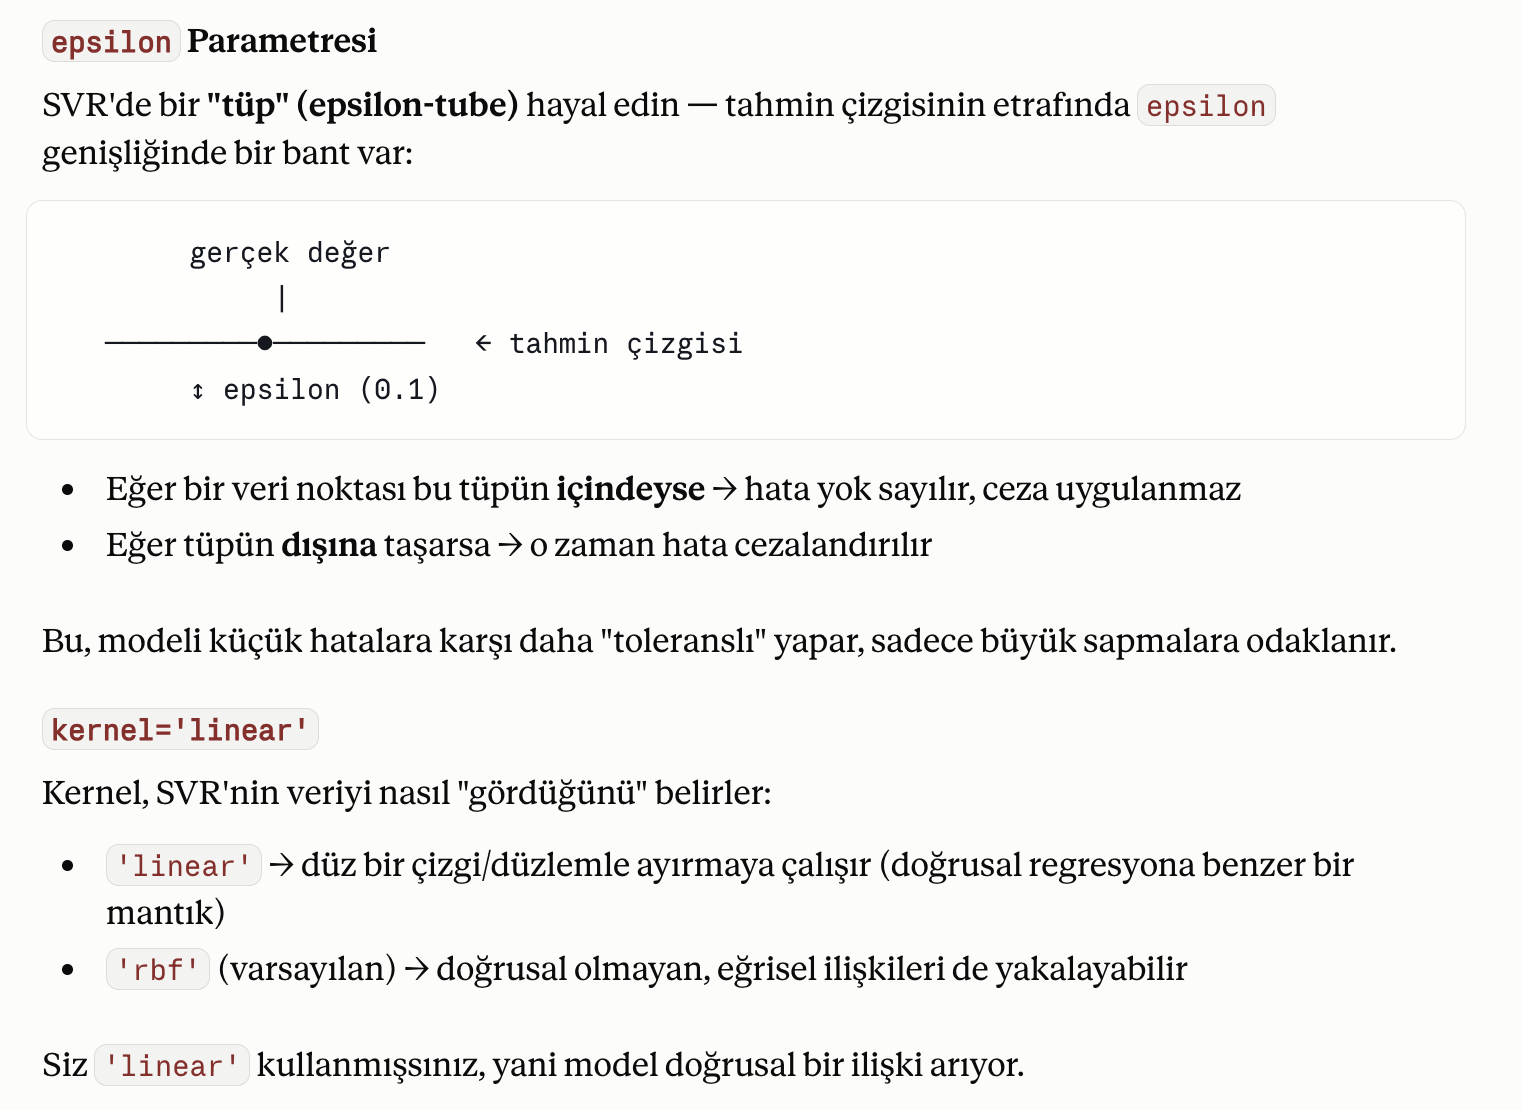

In [ ]:
y_pred_svr = svr.predict(X_test)
mse = mean_squared_error(y_test,y_pred_svr)
print('Hata skoru : ',mse)

Hata skoru :  0.03974136369415256
